<a href="https://colab.research.google.com/github/srima231/Bank-Loan-Data-Analysis-Risk-Insights/blob/main/Banking_Loan_DA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

In [ ]:
df=pd.read_excel("/content/financial_loan.xlsx")
df

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677


In [ ]:
df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,2021-07-11,2021-05-16,2021-05-16,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


In [ ]:
df.shape

(38576, 24)

In [ ]:
df.dtypes

,0
id,int64
address_state,object
application_type,object
emp_length,object
emp_title,object
grade,object
home_ownership,object
issue_date,datetime64[ns]
last_credit_pull_date,datetime64[ns]
last_payment_date,datetime64[ns]


In [ ]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


***Total Loan Application***

In [ ]:
total_loan_application= df['id'].count()
print(" Total Loan Application: ",total_loan_application)

 Total Loan Application:  38576


***MTD Total Loan Applications***

In [ ]:
# Get latest date
latest_issue_date = df['issue_date'].max() #2021-12-31

# Extract year and month
latest_year = latest_issue_date.year #2021
latest_month = latest_issue_date.month # 12

# Filter data for MTD (Month-To-Date)
mtd_date = df[
    (df['issue_date'].dt.year == latest_year) &
    (df['issue_date'].dt.month == latest_month)] # keeps latest date like (2021-12-01 ,2021-12-31)

# Count loan applications
mtd_loan_applications = mtd_date['id'].count()

# Print result
print(f"MTD Loan Applications (for {latest_issue_date.strftime('%B %Y')}): {mtd_loan_applications}")

MTD Loan Applications (for December 2021): 4314


**Total Funded Amount**

In [ ]:
total_loan_amount=df['loan_amount'].sum()/1000000
print("Total Funded Amount: ${:.2f}M".format(total_loan_amount))

Total Funded Amount: $435.76M


***MTD Funded Amount***

In [ ]:
# Get latest date
latest_issue_date = df['issue_date'].max()

# Extract year and month
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

# Filter data for MTD (Month-To-Date)
mtd_date = df[
    (df['issue_date'].dt.year == latest_year) &
    (df['issue_date'].dt.month == latest_month)
]

# Calculate MTD funded amount (in millions)
mtd_funded_amount = mtd_date['loan_amount'].sum() / 1000000

# Print result
print("MTD Total Funded Amount: ${:.2f}M".format(mtd_funded_amount))

MTD Total Funded Amount: $53.98M


***Total Amount Received***

In [ ]:
total_amount_receved=df['total_payment'].sum()/1000000
print("Total Amount Received: ${:.2f}M".format(total_amount_receved))

Total Amount Received: $473.07M


***MTD Total Amount Received***

In [ ]:
# Get latest date
latest_issue_date = df['issue_date'].max()

# Extract year and month
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

# Filter data for MTD (Month-To-Date)
mtd_date = df[
    (df['issue_date'].dt.year == latest_year) &
    (df['issue_date'].dt.month == latest_month)
]

# Calculate MTD funded amount (in millions)
mtd_amount_received = mtd_date['total_payment'].sum() / 1000000

# Print result
print("MTD Total Amount Received : ${:.2f}M".format(mtd_amount_received))

MTD Total Amount Received : $58.07M


***Average Intrest Rate***

In [ ]:
# Calculate the average interest rate from the "int_rate" column
# .mean() gives the average value
# * 100 converts decimal to percentage format
Avg_interest_rate = df["int_rate"].mean() * 100

# Print the average interest rate
# {:.2f} formats the value to 2 decimal places
# % symbol is added at the end for percentage display
print("Avg Int Rate: {:.2f}%".format(Avg_interest_rate))

Avg Int Rate: 12.05%


***Average Debit to Income Ratio***

In [ ]:
Avg_debit_income = df["dti"].mean() * 100
print("Avg Debit Income Rate: {:.2f}%".format(Avg_debit_income))

Avg Debit Income Rate: 13.33%


***Good Loan Metrics***

In [ ]:
# Filter only good loans (Fully Paid and Current loans)
good_loans = df[df['loan_status'].isin(["Fully Paid", "Current"])]

# Count total number of loan applications
total_loan_applications = df['id'].count()

# Count number of good loan applications
good_loan_applications = good_loans['id'].count()

# Calculate total amount funded for good loans
good_loan_funded_amount = good_loans['loan_amount'].sum()

# Calculate total amount received from good loans
good_loan_received = good_loans['total_payment'].sum()

# Convert funded amount into millions for better readability
good_loan_funded_amount_millions = good_loan_funded_amount / 1000000

# Convert received amount into millions
good_loan_received_millions = good_loan_received / 1000000

# Calculate percentage of good loan applications
good_loan_percentage = (good_loan_applications / total_loan_applications) * 100

# Print total number of good loan applications
print("Good Loan Applications:", good_loan_applications)

# Print funded amount in millions (formatted to 2 decimal places)
print("Good Loan Funded Amount (in Millions): ${:.2f}M".format(good_loan_funded_amount_millions))

# Print total received amount in millions
print("Good Loan Total Received (in Millions): ${:.2f}M".format(good_loan_received_millions))

# Print percentage of good loans
print("Percentage of Good Loan Applications: {:.2f}%".format(good_loan_percentage))

Good Loan Applications: 33243
Good Loan Funded Amount (in Millions): $370.22M
Good Loan Total Received (in Millions): $435.79M
Percentage of Good Loan Applications: 86.18%


***Bad Loan Metrics***

In [ ]:
# Filter only Bad loans (Fully Paid and Current loans)
bad_loans = df[df['loan_status'].isin(["Charged Off"])]

# Count total number of loan applications
total_loan_applications = df['id'].count()

# Count number of bad loan applications
bad_loan_applications = bad_loans['id'].count()

# Calculate total amount funded for bad loans
bad_loan_funded_amount = bad_loans['loan_amount'].sum()

# Calculate total amount received from bad loans
bad_loan_received = bad_loans['total_payment'].sum()

# Convert funded amount into millions for better readability
bad_loan_funded_amount_millions = bad_loan_funded_amount / 1_000_000

# Convert received amount into millions
bad_loan_received_millions = bad_loan_received / 1_000_000

# Calculate percentage of good loan applications
bad_loan_percentage = (bad_loan_applications / total_loan_applications) * 100

# Print total number of good loan applications
print("Bad Loan Applications:", bad_loan_applications)

# Print funded amount in millions (formatted to 2 decimal places)
print("Bad Loan Funded Amount (in Millions): ${:.2f}M".format(bad_loan_funded_amount_millions))


# Print total received amount in millions
print("Bad Loan Total Received (in Millions): ${:.2f}M".format(bad_loan_received_millions))

# Print percentage of good loans
print("Percentage of Bad Loan Applications: {:.2f}%".format(bad_loan_percentage))

Bad Loan Applications: 5333
Bad Loan Funded Amount (in Millions): $65.53M
Bad Loan Total Received (in Millions): $37.28M
Percentage of Bad Loan Applications: 13.82%


***Monthly Trend by Issue Date for Total Funded Amount***

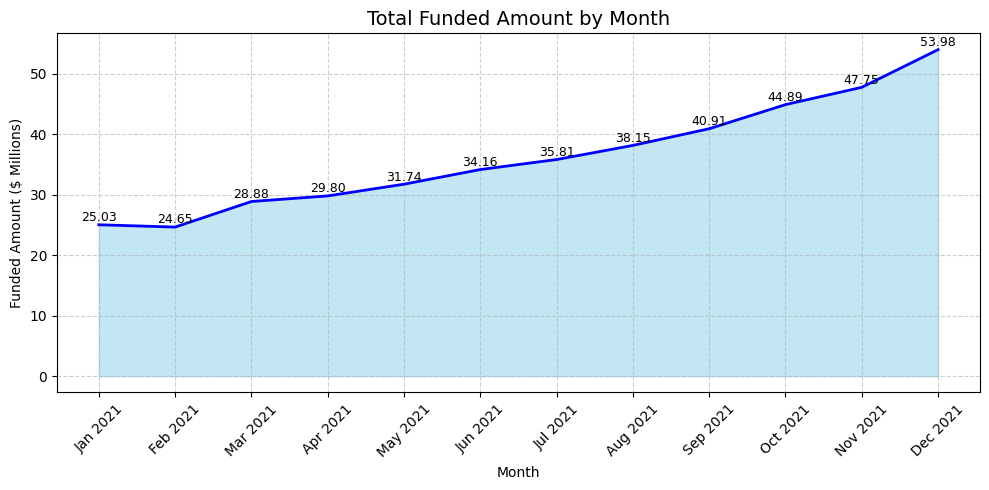

In [ ]:
# Create a monthly funded dataset
monthly_funded = (
    df.sort_values('issue_date')
    # Sort the dataframe by issue_date in ascending order

    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    # Create a new column 'month_name' (e.g., Jan 2023) from issue_date

    .groupby('month_name', sort=False)['loan_amount']
    # Group data by month_name and select loan_amount column

    .sum()
    # Calculate total loan amount for each month

    .div(1000000)
    # Convert values into millions (divide by 10 lakh)

    .reset_index(name='loan_amount_millions')
    # Reset index and rename column to 'loan_amount_millions'
)

# Create figure with specific size
plt.figure(figsize=(10, 5))

# Fill area under the line chart
plt.fill_between(
    monthly_funded['month_name'],
    monthly_funded['loan_amount_millions'],
    color='skyblue', alpha=0.5 # for transparent(0-Fully transparent,1-Fully solid)
)

# Plot the line chart
plt.plot(
    monthly_funded['month_name'],
    monthly_funded['loan_amount_millions'],
    color='blue', linewidth=2
)

# Add text labels for each data point
for i, row in monthly_funded.iterrows(): #loops through dataframe rows one by one.
    plt.text(
        i,
        row['loan_amount_millions'] + 0.1,  # Slightly above the point(5.20*)
        f"{row['loan_amount_millions']:.2f}",  # Format to 2 decimal places
        ha='center', va='bottom', fontsize=9,color='black'
    )

# Add chart title
plt.title('Total Funded Amount by Month', fontsize=14)

# Label x-axis
plt.xlabel('Month')

# Label y-axis
plt.ylabel('Funded Amount ($ Millions)')

# Set x-axis ticks and rotate labels for better readability
plt.xticks(
    ticks=range(len(monthly_funded)),#Creates positions for x-axis labels(Matplotlib needs numeric positions internally)
    labels=monthly_funded['month_name'],
    rotation=45
)

# Add grid lines
plt.grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()

***Monthly Trend by Issue Date for Total Amount Received***

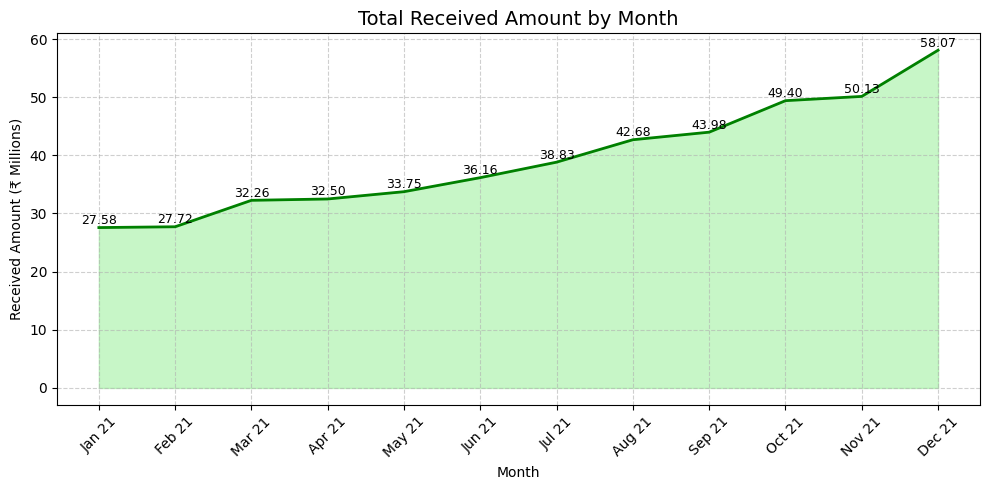

In [ ]:
# =======================
# Step 1: Prepare Data
# =======================

# Create a DataFrame that calculates total received amount per month
monthly_received = (
    df.sort_values('issue_date')  # Sort data by issue date

    # Create 'month_name' column like "Jan 23"
    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %y'))

    # Group by month and select total_payment column
    .groupby('month_name', sort=False)['total_payment']

    # Sum total payments for each month
    .sum()

    # Convert values to millions
    .div(1000000)

    # Convert to DataFrame and rename column
    .reset_index(name='received_amount_millions')
)

# =======================
# Step 2: Plot the Chart
# =======================

# Create figure
plt.figure(figsize=(10, 5))

# Area chart (filled region)
plt.fill_between(
    monthly_received['month_name'],                  # X-axis
    monthly_received['received_amount_millions'],    # Y-axis
    color='lightgreen',                              # Fill color
    alpha=0.5                                        # Transparency
)

# Line chart on top
plt.plot(
    monthly_received['month_name'],
    monthly_received['received_amount_millions'],
    color='green',
    linewidth=2
)

# =======================
# Step 3: Add Data Labels
# =======================

# Add value labels on each point
for i, row in monthly_received.iterrows():
    plt.text(
        i,
        row['received_amount_millions'] + 0.1,       # Slightly above the point
        f"{row['received_amount_millions']:.2f}",    # Format to 2 decimals
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )

# =======================
# Step 4: Formatting
# =======================

# Title and labels
plt.title('Total Received Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Received Amount (₹ Millions)')

# X-axis ticks formatting
plt.xticks(
    ticks=range(len(monthly_received)),
    labels=monthly_received['month_name'],
    rotation=45
)

# Grid for readability
plt.grid(True, linestyle='--', alpha=0.6)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

***Monthly Trend by Issue Date for Total Loan Applications***



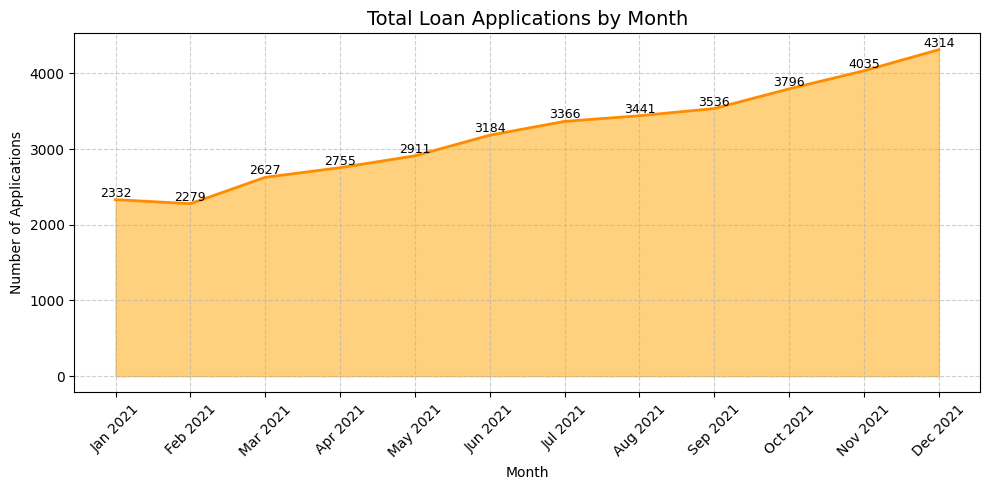

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# STEP 1: Prepare Monthly Data
# ================================

monthly_applications = (
    df.sort_values('issue_date')
    # Sort data by issue date

    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    # Create month-year column like "Jan 2023"

    .groupby('month_name', sort=False)['id']
    # Group by month and select 'id'

    .count()
    # Count number of applications per month

    .reset_index(name='loan_applications_count')
    # Convert to DataFrame and rename column
)

# ================================
# STEP 2: Create Visualization
# ================================

plt.figure(figsize=(10, 5))

# Area chart (fill under line)
plt.fill_between(
    monthly_applications['month_name'],
    monthly_applications['loan_applications_count'],
    color='orange',
    alpha=0.5
)

# Line chart
plt.plot(
    monthly_applications['month_name'],
    monthly_applications['loan_applications_count'],
    color='darkorange',
    linewidth=2
)

# ================================
# STEP 3: Add Data Labels
# ================================

for i, row in monthly_applications.iterrows():
    plt.text(
        i,
        row['loan_applications_count'] + 0.5,
        f"{row['loan_applications_count']}",
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )

# ================================
# STEP 4: Formatting
# ================================

plt.title('Total Loan Applications by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Applications')

plt.xticks(
    ticks=range(len(monthly_applications)),
    labels=monthly_applications['month_name'],
    rotation=45
)

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

# ================================
# STEP 5: Show Plot
# ================================

plt.show()

***Regional Analysis By State Total Funded Amount***



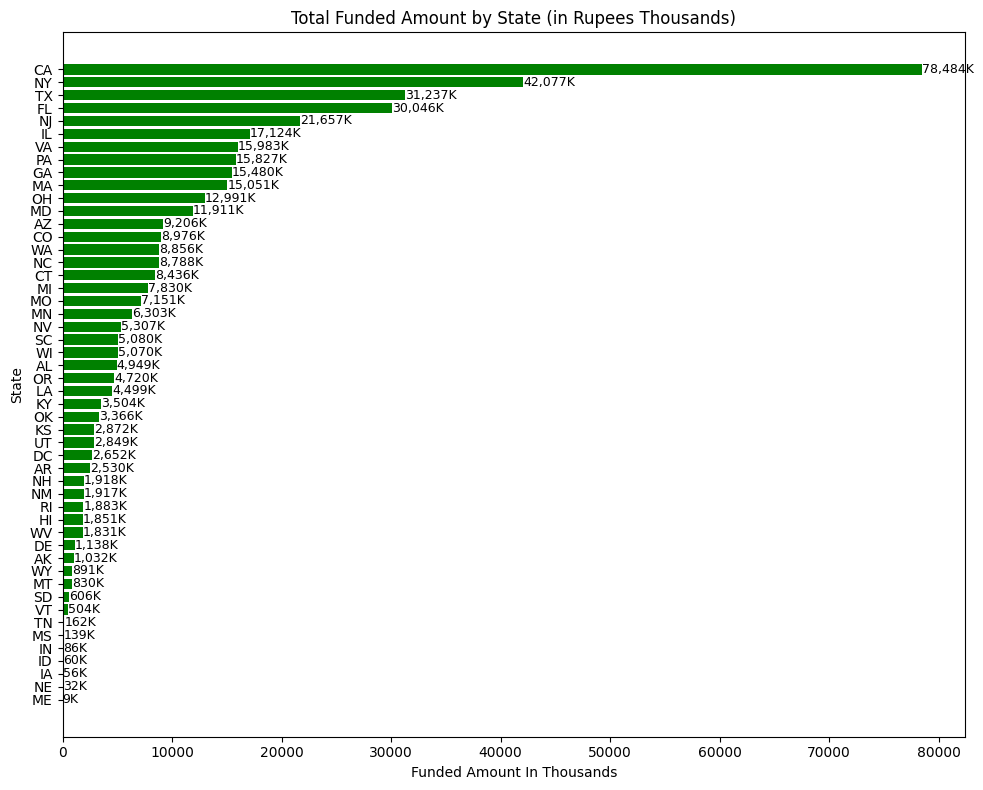

In [ ]:
# Group the DataFrame by 'address_state', sum the 'loan_amount' for each state, and sort in ascending order
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)

# Convert the loan amounts from units to thousands (divide by 1000)
state_funding_thousands = state_funding / 1000

# Set the figure size to 10 inches wide and 8 inches tall
plt.figure(figsize=(10, 8))

# Create a horizontal bar chart using state names as y-axis and funding amounts as x-axis, with light coral color
bars=plt.barh(state_funding_thousands.index, state_funding_thousands.values, color='green')

# Loop through each bar in the chart to add data labels
for bar in bars:
    # Get the width (value) of the current bar
    width = bar.get_width()

    # Add a text label at the end of each bar showing the value in 'K' (thousands) format
    # Positioned 10 units to the right of the bar end, vertically centered on the bar
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2,
             f'{width:,.0f}K', va='center', fontsize=9)


# Set the chart title with rupee symbol indicating values are in thousands
plt.title('Total Funded Amount by State (in Rupees Thousands)')

# Label the x-axis showing funded amount in thousands
plt.xlabel('Funded Amount In Thousands')

# Label the y-axis as 'State'
plt.ylabel('State')

# Automatically adjust subplot parameters to give specified padding
plt.tight_layout()

# Display the final chart
plt.show()

***Loan Term Analysis by Total Funded Amount***




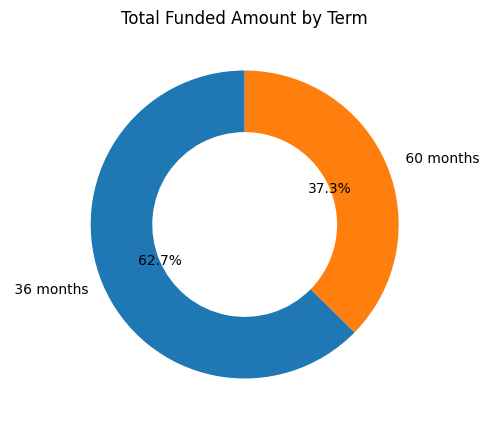

In [ ]:
# Total funded amount by term (in millions)
term_funding = df.groupby('term')['loan_amount'].sum() / 1000000

# Create chart size
plt.figure(figsize=(5,5))

# Create donut chart
plt.pie(
    term_funding,
    labels=term_funding.index,
    autopct='%1.1f%%',#Float with 1 decimal place
    startangle=90,
    wedgeprops={'width':0.4}
)

# Add title
plt.title('Total Funded Amount by Term')

# Show chart
plt.show()

***Employee Length by Total Funded Amount***




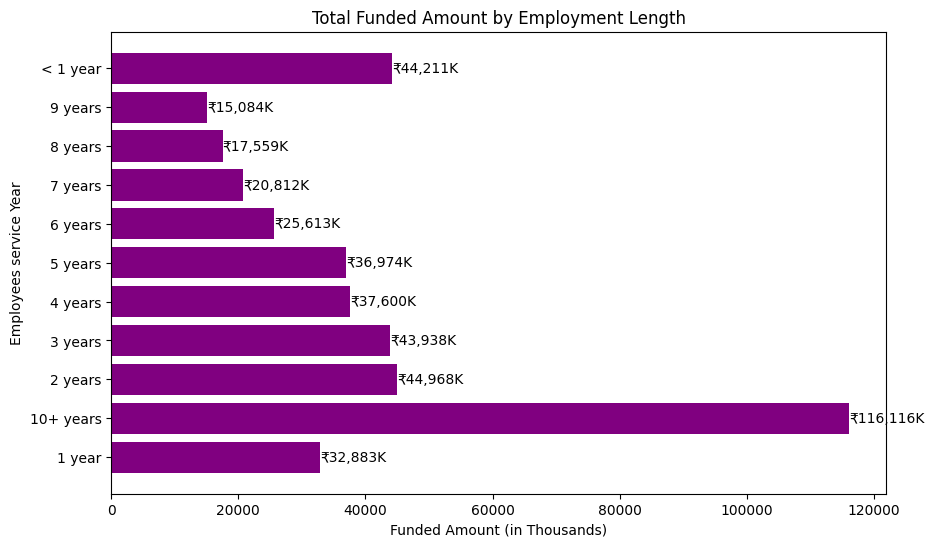

In [ ]:
# Total funded amount by employment length
emp_funding = df.groupby('emp_length')['loan_amount'].sum() / 1000

# Create chart size
plt.figure(figsize=(10,6))

# Create horizontal bar chart
bars = plt.barh(emp_funding.index, emp_funding, color='purple')

# Add value labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 5,
        bar.get_y() + bar.get_height()/2,
        f"\u20B9{width:,.0f}K",
        va='center'
    )

# Add labels and title
plt.xlabel("Funded Amount (in Thousands)")
plt.ylabel("Employees service Year")
plt.title("Total Funded Amount by Employment Length")

# Show chart
plt.show()

***Loan Purpose by Total Funded Amount***




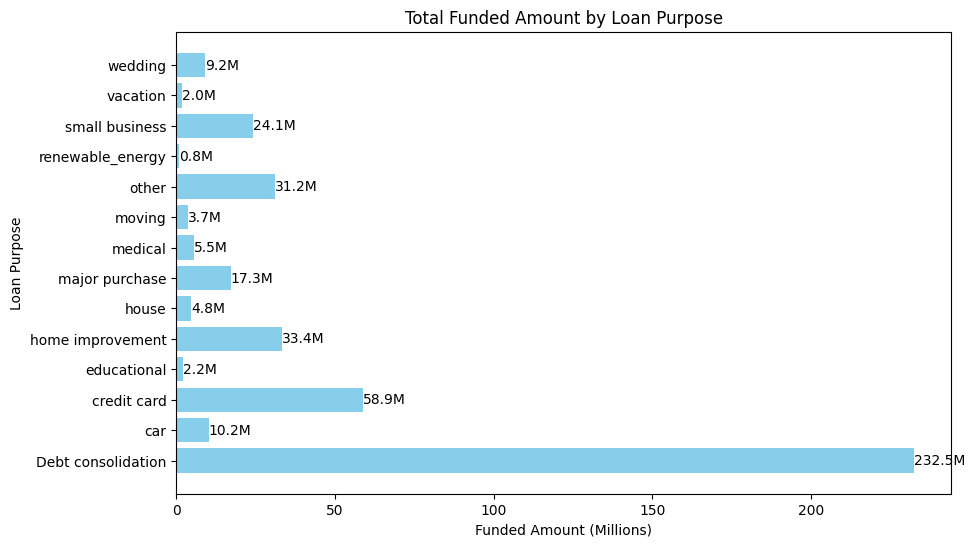

In [ ]:
# Group by loan purpose and calculate total funded amount in millions
purpose_funding = df.groupby('purpose')['loan_amount'].sum() / 1000000

# Create figure
plt.figure(figsize=(10, 6))

# Create horizontal bar chart
bars = plt.barh(purpose_funding.index, purpose_funding.values, color='skyblue')

# Add value labels
for bar in bars:
    plt.text(
        bar.get_width(),                      # X position
        bar.get_y() + bar.get_height()/2,    # Y position
        f'{bar.get_width():.1f}M',           # Label text
        va='center'
    )

# Add title and labels
plt.title('Total Funded Amount by Loan Purpose')
plt.xlabel('Funded Amount (Millions)')
plt.ylabel('Loan Purpose')
# Display chart
plt.show()